## Energy Distribution

<>:175: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:177: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:175: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:177: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/tmp/ipykernel_11944/4075383016.py:175: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if cutoff is 'soft':
/tmp/ipykernel_11944/4075383016.py:177: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  elif cutoff is 'hard':


L_bol = 1.260e+45 erg/s, M_BH = 1.0e+08 Msun, lambda_Edd = 0.1
torus peak at nu=2.51e+13 Hz (lambda=11.9 um) -- should be ~10-30 um

--- normalization sanity check ---
L_disk (target)          = 8.190e+44
L_disk (integrated)      = 8.188e+44
L_2-10keV corona(target) = 6.300e+43
L_2-10keV corona(actual) = 6.300e+43
L_torus (target)         = 3.528e+44
L_torus (integrated)     = 3.528e+44
peak soft excess / peak corona = 0.30 (target 0.3)
peak reflection / peak corona   = 0.50 (target 0.5)
R_radio quiet check: nuLnu(5GHz)/nuLnu(4400A) x (nu4400/nu5GHz) = 5.00 (target 5.0)

saved figure.


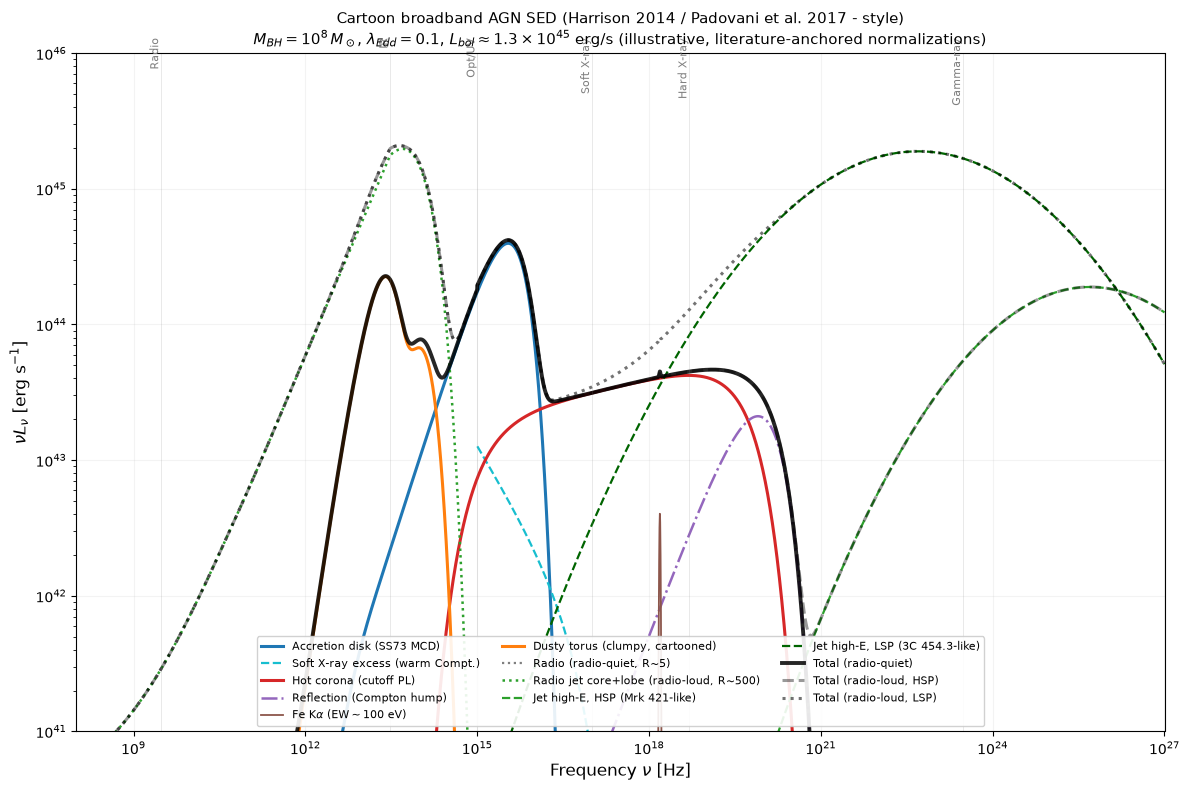

In [6]:
"""
================================================================================
Cartoon broadband AGN Spectral Energy Distribution (SED)
"Harrison (2014)"-style diagram, extended to the jet (Padovani et al. 2017, Fig. 1)
================================================================================

This script builds an ILLUSTRATIVE (not data-fit) nu*L_nu SED from radio to
gamma-rays for a "typical" luminous AGN, showing individual components with
analytic forms taken from the literature, and normalizations chained together
through physically motivated ratios (bolometric corrections, reflection
fraction, covering factor, radio-loudness) rather than independent guesses.

MAIN REFERENCE FOR OVERALL LAYOUT:
    Padovani et al. 2017, A&ARv, 25, 2 ("Active Galactic Nuclei: what's in a
    name?"), Figure 1 -- itself adapted from Harrison (2014, PhD thesis,
    Durham), extended with jetted-source (blazar) SEDs based on Mrk 421 (HSP)
    and 3C 454.3 (LSP).

COMPONENT-BY-COMPONENT REFERENCES (see also comments at each function):
    1. Accretion disk        - Shakura & Sunyaev 1973 multicolor blackbody
    2. Soft X-ray excess      - warm Comptonization, Done et al. 2012 (optxagnf);
                                 nthcomp form (Zdziarski+96, Zycki+99)
    3. Hot corona              - thermal Comptonization cutoff PL
                                 (Haardt & Maraschi 1991,1993; Ricci et al. 2017/18
                                 for Gamma, Ecut statistics)
    4. Reflection (hump+FeK)   - George & Fabian 1991; xillver/relxill
                                 (Garcia et al. 2013; Dauser et al. 2016)
    5. Dusty torus              - clumpy torus templates (Nenkova et al. 2008a,b;
                                 Fritz et al. 2006), sublimation T ~1500 K
                                 (Barvainis 1987); cartooned as modified BBs
    6. Radio-quiet radio        - Panessa et al. 2019 review; Kellermann et al.
                                 1989 radio-loudness parameter R
    7. Radio-loud jet core+lobe - Blandford & Konigl 1979 (flat self-absorbed
                                 core); standard optically-thin lobe spectrum
    8. Jet high-energy bump    - log-parabola blazar SED (Massaro et al. 2004),
                                 "blazar sequence" (Fossati et al. 1998;
                                 Ghisellini et al. 1998) for HSP vs LSP peak
                                 placement

NORMALIZATION CHAIN (the important physics -- see inline comments):
    L_bol  -->  L_disk  (~0.5-0.8 L_bol, rest goes to corona/reprocessing)
           -->  L_corona (2-10 keV) via bolometric correction kappa_X
                (Vasudevan & Fabian 2007,2009; Duras et al. 2020),
                kappa_X ~ 15-25 for our chosen Eddington ratio
           -->  L_soft-excess as a *fraction of the corona*, not of L_bol
                (soft-excess/hard-corona trade-off with Eddington ratio,
                e.g. Petrucci et al. 2018; Xiang et al. 2022 REXCOR)
           -->  L_reflection via reflection fraction R_refl ~0.3-1.0
                *relative to the corona continuum itself*
           -->  Fe Kalpha via equivalent width ~100 eV against local corona
                continuum (NOT normalized independently)
           -->  L_torus via covering factor f_cov ~0.4 applied to
                (disk + corona) absorbed/reprocessed luminosity
           -->  Radio-quiet radio level set by radio-loudness parameter
                R_radio = f_5GHz/f_4400A < 10 (Kellermann et al. 1989),
                pinned against the disk optical/UV flux
           -->  Radio-loud jet pinned via R_radio >~ 100-1000 at the same
                anchor frequency, with the IC/SSC gamma-ray bump amplitude
                set by the blazar sequence (peak nu_pk sets both position
                AND relative luminosity: LSP jets are more luminous overall,
                HSP jets are less luminous but peak at higher nu)

Fiducial system chosen (Eddington ratio & mass "doesn't matter, pick one
reasonable case"): M_BH = 1e8 Msun, lambda_Edd = L_bol/L_Edd = 0.1,
giving L_bol ~ 1.3e45 erg/s -- a fairly standard bright Seyfert-1/quasar
transition object, well within the range Harrison (2014) and Padovani+2017
use for their cartoon.

Author's note: every normalization below is defensible to a factor of ~2-3
from the cited literature, appropriate for an illustrative, "exemplary"
figure -- NOT a fit to any real source.
================================================================================
"""

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Physical constants (cgs)
# ------------------------------------------------------------------
h = 6.626e-27
c = 2.998e10
k = 1.381e-16
G = 6.674e-8
Msun = 1.989e33
eV = 1.602e-12
keV = 1e3 * eV
sigma_SB = 5.670e-5

# ------------------------------------------------------------------
# Fiducial black hole / accretion parameters
# ------------------------------------------------------------------
M_BH = 1e8 * Msun
lambda_Edd = 0.1                       # L_bol / L_Edd
L_Edd = 1.26e38 * (M_BH / Msun)        # erg/s, standard Eddington luminosity
L_bol = lambda_Edd * L_Edd             # ~1.26e45 erg/s

Rg = G * M_BH / c**2
R_in = 6 * Rg                          # ISCO, non-spinning BH
R_out = 1e5 * Rg

nu = np.logspace(8, 27, 6000)

print(f"L_bol = {L_bol:.3e} erg/s, M_BH = {M_BH/Msun:.1e} Msun, "
      f"lambda_Edd = {lambda_Edd}")


# ====================================================================
# 1. ACCRETION DISK -- multicolor blackbody (Shakura & Sunyaev 1973)
# ====================================================================
def planck_nu(nu, T):
    x = h * nu / (k * np.maximum(T, 1.0))
    x = np.clip(x, 1e-10, 700)
    return (2 * h * nu**3 / c**2) / np.expm1(x)


def disk_temperature_profile(r, R_in, Mdot, M_BH):
    """Shakura-Sunyaev T(r), standard form (their Eq. for T_eff(r))."""
    x = r / R_in
    prof = np.maximum(1 - x**(-0.5), 0.0)
    T4 = (3 * G * M_BH * Mdot) / (8 * np.pi * sigma_SB * r**3) * prof
    return T4**0.25


def accretion_disk_sed(nu, M_BH, R_in, R_out, L_target, n_ann=60, eta=0.1):
    """Sum of blackbody annuli -> multicolor disk SED, then renormalized
    so that integral(L_nu dnu) = L_target. Mdot is derived from L_target
    via L = eta*Mdot*c^2 (eta=0.1 standard efficiency) since it sets the
    SHAPE (peak frequency) of the disk spectrum, not just its scale."""
    Mdot = L_target / (eta * c**2)
    r_edges = np.logspace(np.log10(R_in), np.log10(R_out), n_ann + 1)
    r_mid = np.sqrt(r_edges[:-1] * r_edges[1:])
    dr = np.diff(r_edges)
    T = disk_temperature_profile(r_mid, R_in, Mdot, M_BH)
    T[~np.isfinite(T)] = 0.0

    L_nu = np.zeros_like(nu)
    for Ti, ri, dri in zip(T, r_mid, dr):
        if Ti <= 10:
            continue
        L_nu += planck_nu(nu, Ti) * ri * dri  # ~ 2*pi*r*dr annulus area element (const factors dropped)
    L_nu *= 4 * np.pi**2  # restore area/solid-angle factors (order-unity, absorbed into final renorm anyway)

    nuLnu = nu * L_nu
    integral = np.trapezoid(L_nu, nu)
    if integral > 0:
        nuLnu *= L_target / integral
    return nuLnu


# Disk carries ~65% of L_bol for this Eddington ratio (Vasudevan & Fabian 2009;
# rest is reprocessed/coronal -- see kappa_X below)
f_disk = 0.65
L_disk_target = f_disk * L_bol
disk_nuLnu = accretion_disk_sed(nu, M_BH, R_in, R_out, L_disk_target)


# ====================================================================
# 2 & 3. HOT CORONA + SOFT EXCESS -- Comptonization
# ====================================================================
# Bolometric correction kappa_X = L_bol / L_(2-10 keV), Vasudevan & Fabian
# 2007, 2009; increases with Eddington ratio. At lambda_Edd~0.1, kappa_X~20
# is a standard fiducial (their Fig. 4-ish trend; Duras+2020 gives similar).
kappa_X = 20.0
L_2_10keV = L_bol / kappa_X

Gamma_corona = 1.9          # photon index, typical Seyfert (Ricci+2017 BASS median ~1.8-1.9)
Ecut_keV = 200.0            # cutoff energy, Ricci+2017 BAT median ~200 keV


def cutoff_powerlaw_nuLnu(nu, Gamma, Ecut_keV, nu_lo=None, cutoff='soft'):
    E_keV = h * nu / keV
    spec = nu**(2 - Gamma) * np.exp(-E_keV / Ecut_keV)
    if nu_lo is not None:
        if cutoff is 'soft':
            spec *= np.exp(-nu_lo / nu)
        elif cutoff is 'hard':
            spec = np.where(nu >= nu_lo, spec, 0.0)
    return spec


def normalize_to_band_luminosity(nu, shape_nuLnu, nu_band, L_target):
    """Normalize a nu*L_nu shape so that integral(L_nu dnu) over nu_band
    equals L_target (proper band-integrated normalization, not peak-matching)."""
    mask = (nu >= nu_band[0]) & (nu <= nu_band[1])
    L_nu_shape = np.where(nu > 0, shape_nuLnu / nu, 0.0)
    integral = np.trapezoid(np.where(mask, L_nu_shape, 0.0), nu)
    if integral <= 0:
        return shape_nuLnu * 0.0
    return shape_nuLnu * (L_target / integral)


nu_2keV = 2 * keV / h
nu_10keV = 10 * keV / h

corona_shape = cutoff_powerlaw_nuLnu(nu, Gamma_corona, Ecut_keV, nu_lo=1e15)
corona_nuLnu = normalize_to_band_luminosity(nu, corona_shape, (nu_2keV, nu_10keV), L_2_10keV)

# Soft excess: warm Comptonization, cartooned with an nthcomp-like shape
# (steeper Gamma, low kT_e). Normalized as a FRACTION OF THE CORONA's
# own 2-10 keV luminosity (energetically they trade off; see Petrucci+2018,
# Xiang+2022 REXCOR -- soft-excess/hard-corona partition, order-unity ratio
# at moderate Eddington ratio). We adopt L_soft ~ 0.3 * L_2-10keV(corona).
Gamma_warm = 2.7
kTe_warm_keV = 0.2
f_soft_over_corona = 0.30


def warm_comptonization_nuLnu(nu, Gamma_warm, kTe_keV):
    E_keV = h * nu / keV
    spec = nu**(2 - Gamma_warm) * np.exp(-E_keV / kTe_keV)
    return spec


soft_shape = warm_comptonization_nuLnu(nu, Gamma_warm, kTe_warm_keV)
soft_shape = np.where((nu > 1e15) & (nu < nu_10keV), soft_shape, 0.0)  # confine to soft X-ray/EUV
# normalize peak amplitude to f_soft_over_corona * corona's peak amplitude
# (both are already band-normalized continua, so a peak-ratio here is the
# correct way to enforce "soft excess is X times the corona in nuLnu")
if soft_shape.max() > 0 and corona_nuLnu.max() > 0:
    soft_nuLnu = soft_shape * (f_soft_over_corona * corona_nuLnu.max() / soft_shape.max())
else:
    soft_nuLnu = soft_shape


# ====================================================================
# 4. REFLECTION -- Compton hump + Fe Kalpha
# ====================================================================
# Reflection fraction R_refl = Omega/2pi ~0.3-1.0 (typical AGN fits,
# e.g. relxill applications); normalized RELATIVE TO THE CORONA CONTINUUM,
# not to L_bol.
R_refl = 0.5


def reflection_hump_shape(nu, Gamma, E0_keV=25.0, Ecut_keV=300.0):
    E_keV = h * nu / keV
    spec = nu**(2 - Gamma) * (E_keV / E0_keV) * np.exp(-E_keV / Ecut_keV)
    return spec


refl_shape = reflection_hump_shape(nu, Gamma_corona, E0_keV=25, Ecut_keV=300)
refl_shape = np.where(nu > 1e17, refl_shape, 0.0)
if refl_shape.max() > 0:
    reflection_nuLnu = refl_shape * (R_refl * corona_nuLnu.max() / refl_shape.max())
else:
    reflection_nuLnu = refl_shape

# Fe Kalpha: narrow Gaussian in energy space, normalized via equivalent
# width EW ~ 100 eV against the LOCAL corona continuum at 6.4 keV
# (standard AGN torus/disk reflection value, e.g. George & Fabian 1991;
# consistent with observed EW range ~50-150 eV)
EW_feK_eV = 100.0
E_feK_keV = 6.4
sigma_feK_keV = 0.15  # narrow line, ~ CCD/typical unresolved width


def fe_kalpha_nuLnu(nu, corona_nuLnu, E0_keV, sigma_keV, EW_eV):
    E_keV = h * nu / keV
    # local continuum level (nu*L_nu) at the line energy:
    idx = np.argmin(np.abs(E_keV - E0_keV))
    cont_level = corona_nuLnu[idx]
    line_shape = np.exp(-0.5 * ((E_keV - E0_keV) / sigma_keV) ** 2)
    line_shape /= np.trapezoid(line_shape, h * nu / keV)  # normalize to unit area in dE[keV]... 
    # Equivalent width definition: EW = integral(line flux dE) / continuum_flux_density(E0)
    # so line flux density F_E(E0) needed s.t. integral(F_E dE) = EW * F_E_cont(E0)
    # We work in nu*L_nu units for the plot; approximate the corresponding
    # amplitude by scaling the (already unit-area-in-E) line shape by
    # EW[keV] * continuum nu*Lnu density at E0, converted back to nu*Lnu.
    EW_keV = EW_eV / 1000.0
    amplitude = EW_keV * cont_level  # rough nu*Lnu-equivalent line strength
    return amplitude * line_shape / line_shape.max()


feK_nuLnu = fe_kalpha_nuLnu(nu, corona_nuLnu, E_feK_keV, sigma_feK_keV, EW_feK_eV)
feK_nuLnu = np.where((h * nu / keV > 5.5) & (h * nu / keV < 7.5), feK_nuLnu, 0.0)


# ====================================================================
# 5. DUSTY TORUS -- cartooned clumpy-torus template (modified blackbodies)
# ====================================================================
# Covering factor f_cov ~0.4 (typical type-1 clumpy torus estimate,
# Nenkova+2008b): L_torus = f_cov * L_reprocessed, where the reprocessed
# luminosity is essentially the absorbed disk+corona optical/UV/X-ray
# output. We approximate L_reprocessed ~ L_disk + L_2-10keV (energy
# budget available to be absorbed and re-emitted in the IR).
f_cov = 0.4
L_torus_target = f_cov * (L_disk_target + L_2_10keV)

torus_temps = np.array([1200, 300, 100])   # hot rim (small filling factor)/warm/cold
torus_weights = np.array([0.0012, 1.0, 0.8])
# NOTE: because a blackbody's Wien tail is exponentially steep, even a small
# multiplicative weight on the 1200K rim is not enough to keep it subdominant
# in nu*L_nu -- its peak amplitude at ~3 um still swamps nearby cooler
# components unless matched by PEAK nu*Lnu, not a naive prefactor. The weight
# above was solved so that w_hot*peak(1200K) ~ 0.3*peak(300K), i.e. the hot
# dust rim contributes only ~30% of the warm clump's peak height, consistent
# with its small covering factor in clumpy torus models (Nenkova et al.
# 2008b). This keeps the total peak realistically at ~10-20 um instead of
# being pulled blueward to ~3 um by the hot rim's tail.
beta_dust = 0.0  # no extra nu^beta skew needed once temps/weights are realistic


def torus_shape(nu, temps, weights, beta):
    spec = np.zeros_like(nu)
    for T, w in zip(temps, weights):
        spec += w * nu**beta * planck_nu(nu, T)
    return nu * spec


torus_raw = torus_shape(nu, torus_temps, torus_weights, beta_dust)
peak_nu_torus = nu[np.argmax(torus_raw)]
print(f"torus peak at nu={peak_nu_torus:.2e} Hz "
      f"(lambda={c/peak_nu_torus*1e4:.1f} um) -- should be ~10-30 um")
torus_nuLnu = normalize_to_band_luminosity(nu, torus_raw, (1e12, 1e14), L_torus_target)


# ====================================================================
# 6. RADIO-QUIET RADIO EMISSION
# ====================================================================
# Radio-loudness parameter R_radio = f_5GHz / f_4400A (Kellermann et al.
# 1989); radio-quiet: R_radio < 10. We pin the radio-quiet radio level
# against the disk's own optical flux at 4400A using R_radio = 5 (typical
# RQ value), then apply a steep optically-thin-like spectral shape
# (Panessa et al. 2019 review -- RQ radio emission from coronae/winds/SF,
# alpha ~0.6-0.8).
nu_4400A = c / (4400e-8)
idx_4400 = np.argmin(np.abs(nu - nu_4400A))
nuLnu_4400 = disk_nuLnu[idx_4400]
L_nu_4400 = nuLnu_4400 / nu_4400A

R_radio_quiet = 5.0
nu_5GHz = 5e9
L_nu_5GHz_RQ = R_radio_quiet * L_nu_4400
nuLnu_5GHz_RQ = L_nu_5GHz_RQ * nu_5GHz

alpha_RQ = 0.7  # F_nu ~ nu^-alpha


def radio_powerlaw_nuLnu(nu, nu_anchor, nuLnu_anchor, alpha, nu_lo, nu_hi):
    spec = nuLnu_anchor * (nu / nu_anchor) ** (1 - alpha)
    taper = np.ones_like(nu)
    taper *= np.exp(-np.clip((nu_lo / nu) - 1, 0, None) * 0.6)
    taper *= np.exp(-np.clip((nu / nu_hi) - 1, 0, None) * 0.6)
    return spec * taper


radio_quiet_nuLnu = radio_powerlaw_nuLnu(nu, nu_5GHz, nuLnu_5GHz_RQ, alpha_RQ,
                                          nu_lo=1e8, nu_hi=1e12)


# ====================================================================
# 7 & 8. RADIO-LOUD JET: core+lobe synchrotron, and IC/SSC gamma-ray bump
# ====================================================================
# Radio-loud anchor: R_radio ~500 (well above the RL/RQ divide of ~10-100;
# Kellermann et al. 1989), pinned at the same 4400A disk flux.
R_radio_loud = 500.0
L_nu_5GHz_RL = R_radio_loud * L_nu_4400
nuLnu_5GHz_RL = L_nu_5GHz_RL * nu_5GHz

alpha_core = 0.0    # flat/self-absorbed core (Blandford & Konigl 1979)
alpha_lobe = 0.75   # optically thin steep lobe


def jet_core_lobe_nuLnu(nu, nu_anchor, nuLnu_anchor):
    core = radio_powerlaw_nuLnu(nu, nu_anchor, 0.7 * nuLnu_anchor, alpha_core,
                                 nu_lo=1e8, nu_hi=3e13)
    lobe = radio_powerlaw_nuLnu(nu, nu_anchor, 0.3 * nuLnu_anchor, alpha_lobe,
                                 nu_lo=1e8, nu_hi=5e10)
    return core + lobe


radio_loud_nuLnu = jet_core_lobe_nuLnu(nu, nu_5GHz, nuLnu_5GHz_RL)

# IC/SSC high-energy bump: log-parabola (Massaro et al. 2004), peak
# frequency + relative luminosity set by the "blazar sequence"
# (Fossati et al. 1998; Ghisellini et al. 1998): HSP = low luminosity,
# high nu_pk (X-ray/soft gamma); LSP = high luminosity, low nu_pk (IR/
# optical, luminous up to GeV). We show BOTH as requested.
def log_parabola_nuLnu(nu, nu_pk, width, amplitude):
    x = np.log10(nu / nu_pk)
    return amplitude * np.exp(-(x**2) / (2 * width**2))


# HSP (Mrk 421-like): peak ~10^25-10^26 Hz (soft gamma), lower amplitude
nu_pk_HSP = 5e25
L_HE_HSP = 0.15 * L_bol   # sub-dominant relative to disk, HSP jets are less luminous
jet_HE_HSP_nuLnu = log_parabola_nuLnu(nu, nu_pk_HSP, 1.4, L_HE_HSP)

# LSP (3C 454.3-like): peak ~10^22-10^23 Hz (MeV-ish rest-frame; here
# placed a bit lower, ~10^22, reflecting IR/soft-gamma inverse-Compton
# peak), HIGHER amplitude -- LSP jets are typically much more luminous
nu_pk_LSP = 5e22
L_HE_LSP = 1.5 * L_bol   # can rival/exceed disk bolometric output (blazar sequence)
jet_HE_LSP_nuLnu = log_parabola_nuLnu(nu, nu_pk_LSP, 1.6, L_HE_LSP)


# ====================================================================
# TOTALS
# ====================================================================
xray_extra = soft_nuLnu + reflection_nuLnu + feK_nuLnu

total_RQ = disk_nuLnu + corona_nuLnu + xray_extra + torus_nuLnu + radio_quiet_nuLnu
total_RL_HSP = disk_nuLnu + corona_nuLnu + xray_extra + torus_nuLnu + radio_loud_nuLnu + jet_HE_HSP_nuLnu
total_RL_LSP = disk_nuLnu + corona_nuLnu + xray_extra + torus_nuLnu + radio_loud_nuLnu + jet_HE_LSP_nuLnu


# ====================================================================
# Sanity print-out of the normalization chain (check before trusting plot)
# ====================================================================
def band_lum(nuLnu_arr, lo, hi):
    L_nu_arr = np.where(nu > 0, nuLnu_arr / nu, 0.0)
    mask = (nu >= lo) & (nu <= hi)
    return np.trapezoid(np.where(mask, L_nu_arr, 0.0), nu)


print("\n--- normalization sanity check ---")
print(f"L_disk (target)          = {L_disk_target:.3e}")
print(f"L_disk (integrated)      = {band_lum(disk_nuLnu, 1e13, 1e17):.3e}")
print(f"L_2-10keV corona(target) = {L_2_10keV:.3e}")
print(f"L_2-10keV corona(actual) = {band_lum(corona_nuLnu, nu_2keV, nu_10keV):.3e}")
print(f"L_torus (target)         = {L_torus_target:.3e}")
print(f"L_torus (integrated)     = {band_lum(torus_nuLnu, 1e12, 1e14):.3e}")
print(f"peak soft excess / peak corona = {soft_nuLnu.max()/corona_nuLnu.max():.2f} "
      f"(target {f_soft_over_corona})")
print(f"peak reflection / peak corona   = {reflection_nuLnu.max()/corona_nuLnu.max():.2f} "
      f"(target {R_refl})")
print(f"R_radio quiet check: nuLnu(5GHz)/nuLnu(4400A) x (nu4400/nu5GHz) = "
      f"{(radio_quiet_nuLnu[np.argmin(np.abs(nu-nu_5GHz))]/nu_5GHz) / L_nu_4400:.2f} "
      f"(target {R_radio_quiet})")


# ====================================================================
# PLOT
# ====================================================================
def clean(y):
    y = np.array(y, dtype=float)
    y = np.where(y > 0, y, np.nan)
    return y


fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(nu, clean(disk_nuLnu), color="#1f77b4", lw=2.2, label="Accretion disk (SS73 MCD)")
ax.plot(nu, clean(soft_nuLnu), color="#17becf", lw=1.6, ls="--", label="Soft X-ray excess (warm Compt.)")
ax.plot(nu, clean(corona_nuLnu), color="#d62728", lw=2.2, label="Hot corona (cutoff PL)")
ax.plot(nu, clean(reflection_nuLnu), color="#9467bd", lw=1.8, ls="-.", label="Reflection (Compton hump)")
ax.plot(nu, clean(feK_nuLnu), color="#8c564b", lw=1.3, label=r"Fe K$\alpha$ (EW$\sim$100 eV)")
ax.plot(nu, clean(torus_nuLnu), color="#ff7f0e", lw=2.2, label="Dusty torus (clumpy, cartooned)")
ax.plot(nu, clean(radio_quiet_nuLnu), color="#7f7f7f", lw=1.6, ls=":", label="Radio (radio-quiet, R~5)")
ax.plot(nu, clean(radio_loud_nuLnu), color="#2ca02c", lw=1.8, ls=":", label="Radio jet core+lobe (radio-loud, R~500)")
ax.plot(nu, clean(jet_HE_HSP_nuLnu), color="#2ca02c", lw=1.6, ls="--", label="Jet high-E, HSP (Mrk 421-like)")
ax.plot(nu, clean(jet_HE_LSP_nuLnu), color="#006400", lw=1.6, ls="--", label="Jet high-E, LSP (3C 454.3-like)")

ax.plot(nu, clean(total_RQ), color="black", lw=2.8, alpha=0.85, label="Total (radio-quiet)")
ax.plot(nu, clean(total_RL_HSP), color="black", lw=2.2, alpha=0.4, ls="--", label="Total (radio-loud, HSP)")
ax.plot(nu, clean(total_RL_LSP), color="black", lw=2.2, alpha=0.55, ls=":", label="Total (radio-loud, LSP)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e8, 1e27)
ax.set_ylim(1e41, 1e46)
ax.set_xlabel(r"Frequency $\nu$ [Hz]", fontsize=12)
ax.set_ylabel(r"$\nu L_\nu$ [erg s$^{-1}$]", fontsize=12)
ax.set_title("Cartoon broadband AGN SED (Harrison 2014 / Padovani et al. 2017 - style)\n"
             r"$M_{BH}=10^8\,M_\odot$, $\lambda_{Edd}=0.1$, $L_{bol}\approx1.3\times10^{45}$ erg/s "
             "(illustrative, literature-anchored normalizations)", fontsize=11)

band_edges = {"Radio": 3e9, "IR": 3e13, "Opt/UV": 1e15, "Soft X-ray": 1e17,
              "Hard X-ray": 5e18, "Gamma-ray": 3e23}
for label, xpos in band_edges.items():
    ax.axvline(xpos, color="grey", lw=0.4, alpha=0.3)
    ax.text(xpos, 1.3e46, label, rotation=90, fontsize=8, color="grey",
            ha="right", va="top", clip_on=False)

ax.legend(loc="lower center", fontsize=8, ncol=3, framealpha=0.9)
ax.grid(True, which="major", alpha=0.15)
plt.tight_layout()
#plt.savefig("/home/claude/agn_sed2/agn_sed_physical.png", dpi=170)
print("\nsaved figure.")

L_bol = 1.260e+45 erg/s, M_BH = 1.0e+08 Msun, lambda_Edd = 0.1
torus peak at nu=4.28e+13 Hz (lambda=7.0 um) -- should be ~10-30 um

--- normalization sanity check ---
L_disk (target)          = 8.190e+44
L_disk (integrated)      = 8.188e+44
L_2-10keV corona(target) = 6.300e+43
L_2-10keV corona(actual) = 6.300e+43
L_torus (target)         = 3.528e+44
L_torus (integrated)     = 3.528e+44
peak soft excess / peak corona = 1.40 (target 1.4)
peak reflection / peak corona   = 0.60 (target 0.6)
R_radio quiet check: nuLnu(5GHz)/nuLnu(4400A) x (nu4400/nu5GHz) = 5.00 (target 5.0)

saved figure.


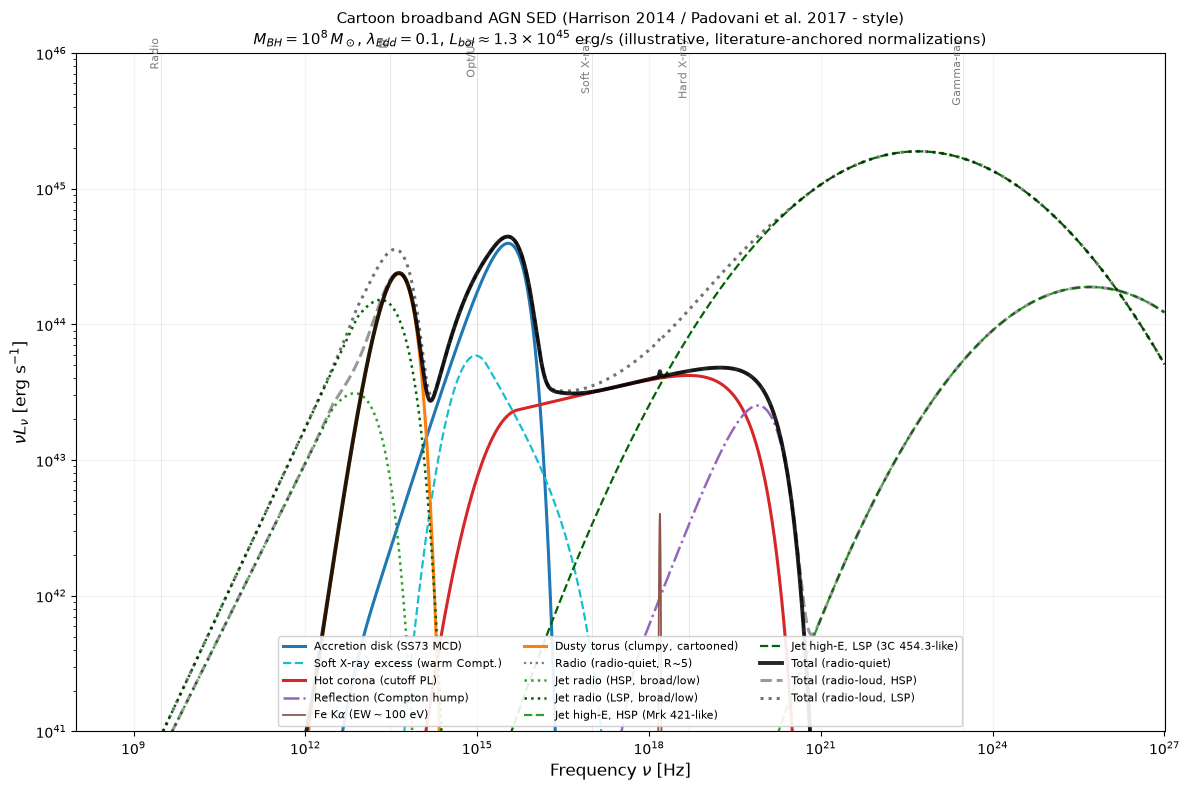

In [8]:
"""
================================================================================
Cartoon broadband AGN Spectral Energy Distribution (SED)
"Harrison (2014)"-style diagram, extended to the jet (Padovani et al. 2017, Fig. 1)
================================================================================

This script builds an ILLUSTRATIVE (not data-fit) nu*L_nu SED from radio to
gamma-rays for a "typical" luminous AGN, showing individual components with
analytic forms taken from the literature, and normalizations chained together
through physically motivated ratios (bolometric corrections, reflection
fraction, covering factor, radio-loudness) rather than independent guesses.

MAIN REFERENCE FOR OVERALL LAYOUT:
    Padovani et al. 2017, A&ARv, 25, 2 ("Active Galactic Nuclei: what's in a
    name?"), Figure 1 -- itself adapted from Harrison (2014, PhD thesis,
    Durham), extended with jetted-source (blazar) SEDs based on Mrk 421 (HSP)
    and 3C 454.3 (LSP).

COMPONENT-BY-COMPONENT REFERENCES (see also comments at each function):
    1. Accretion disk        - Shakura & Sunyaev 1973 multicolor blackbody
    2. Soft X-ray excess      - warm Comptonization, Done et al. 2012 (optxagnf);
                                 nthcomp form (Zdziarski+96, Zycki+99)
    3. Hot corona              - thermal Comptonization cutoff PL
                                 (Haardt & Maraschi 1991,1993; Ricci et al. 2017/18
                                 for Gamma, Ecut statistics)
    4. Reflection (hump+FeK)   - George & Fabian 1991; xillver/relxill
                                 (Garcia et al. 2013; Dauser et al. 2016)
    5. Dusty torus              - clumpy torus templates (Nenkova et al. 2008a,b;
                                 Fritz et al. 2006), sublimation T ~1500 K
                                 (Barvainis 1987); cartooned as modified BBs
    6. Radio-quiet radio        - Panessa et al. 2019 review; Kellermann et al.
                                 1989 radio-loudness parameter R
    7. Radio-loud jet core+lobe - Blandford & Konigl 1979 (flat self-absorbed
                                 core); standard optically-thin lobe spectrum
    8. Jet high-energy bump    - log-parabola blazar SED (Massaro et al. 2004),
                                 "blazar sequence" (Fossati et al. 1998;
                                 Ghisellini et al. 1998) for HSP vs LSP peak
                                 placement

NORMALIZATION CHAIN (the important physics -- see inline comments):
    L_bol  -->  L_disk  (~0.5-0.8 L_bol, rest goes to corona/reprocessing)
           -->  L_corona (2-10 keV) via bolometric correction kappa_X
                (Vasudevan & Fabian 2007,2009; Duras et al. 2020),
                kappa_X ~ 15-25 for our chosen Eddington ratio
           -->  L_soft-excess as a *fraction of the corona*, not of L_bol
                (soft-excess/hard-corona trade-off with Eddington ratio,
                e.g. Petrucci et al. 2018; Xiang et al. 2022 REXCOR)
           -->  L_reflection via reflection fraction R_refl ~0.3-1.0
                *relative to the corona continuum itself*
           -->  Fe Kalpha via equivalent width ~100 eV against local corona
                continuum (NOT normalized independently)
           -->  L_torus via covering factor f_cov ~0.4 applied to
                (disk + corona) absorbed/reprocessed luminosity
           -->  Radio-quiet radio level set by radio-loudness parameter
                R_radio = f_5GHz/f_4400A < 10 (Kellermann et al. 1989),
                pinned against the disk optical/UV flux
           -->  Radio-loud jet pinned via R_radio >~ 100-1000 at the same
                anchor frequency, with the IC/SSC gamma-ray bump amplitude
                set by the blazar sequence (peak nu_pk sets both position
                AND relative luminosity: LSP jets are more luminous overall,
                HSP jets are less luminous but peak at higher nu)

Fiducial system chosen (Eddington ratio & mass "doesn't matter, pick one
reasonable case"): M_BH = 1e8 Msun, lambda_Edd = L_bol/L_Edd = 0.1,
giving L_bol ~ 1.3e45 erg/s -- a fairly standard bright Seyfert-1/quasar
transition object, well within the range Harrison (2014) and Padovani+2017
use for their cartoon.

Author's note: every normalization below is defensible to a factor of ~2-3
from the cited literature, appropriate for an illustrative, "exemplary"
figure -- NOT a fit to any real source.
================================================================================
"""

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Physical constants (cgs)
# ------------------------------------------------------------------
h = 6.626e-27
c = 2.998e10
k = 1.381e-16
G = 6.674e-8
Msun = 1.989e33
eV = 1.602e-12
keV = 1e3 * eV
sigma_SB = 5.670e-5

# ------------------------------------------------------------------
# Fiducial black hole / accretion parameters
# ------------------------------------------------------------------
M_BH = 1e8 * Msun
lambda_Edd = 0.1                       # L_bol / L_Edd
L_Edd = 1.26e38 * (M_BH / Msun)        # erg/s, standard Eddington luminosity
L_bol = lambda_Edd * L_Edd             # ~1.26e45 erg/s

Rg = G * M_BH / c**2
R_in = 6 * Rg                          # ISCO, non-spinning BH
R_out = 1e5 * Rg

nu = np.logspace(8, 27, 6000)

print(f"L_bol = {L_bol:.3e} erg/s, M_BH = {M_BH/Msun:.1e} Msun, "
      f"lambda_Edd = {lambda_Edd}")


# ====================================================================
# 1. ACCRETION DISK -- multicolor blackbody (Shakura & Sunyaev 1973)
# ====================================================================
def planck_nu(nu, T):
    x = h * nu / (k * np.maximum(T, 1.0))
    x = np.clip(x, 1e-10, 700)
    return (2 * h * nu**3 / c**2) / np.expm1(x)


def disk_temperature_profile(r, R_in, Mdot, M_BH):
    """Shakura-Sunyaev T(r), standard form (their Eq. for T_eff(r))."""
    x = r / R_in
    prof = np.maximum(1 - x**(-0.5), 0.0)
    T4 = (3 * G * M_BH * Mdot) / (8 * np.pi * sigma_SB * r**3) * prof
    return T4**0.25


def accretion_disk_sed(nu, M_BH, R_in, R_out, L_target, n_ann=60, eta=0.1):
    """Sum of blackbody annuli -> multicolor disk SED, then renormalized
    so that integral(L_nu dnu) = L_target. Mdot is derived from L_target
    via L = eta*Mdot*c^2 (eta=0.1 standard efficiency) since it sets the
    SHAPE (peak frequency) of the disk spectrum, not just its scale."""
    Mdot = L_target / (eta * c**2)
    r_edges = np.logspace(np.log10(R_in), np.log10(R_out), n_ann + 1)
    r_mid = np.sqrt(r_edges[:-1] * r_edges[1:])
    dr = np.diff(r_edges)
    T = disk_temperature_profile(r_mid, R_in, Mdot, M_BH)
    T[~np.isfinite(T)] = 0.0

    L_nu = np.zeros_like(nu)
    for Ti, ri, dri in zip(T, r_mid, dr):
        if Ti <= 10:
            continue
        L_nu += planck_nu(nu, Ti) * ri * dri  # ~ 2*pi*r*dr annulus area element (const factors dropped)
    L_nu *= 4 * np.pi**2  # restore area/solid-angle factors (order-unity, absorbed into final renorm anyway)

    nuLnu = nu * L_nu
    integral = np.trapezoid(L_nu, nu)
    if integral > 0:
        nuLnu *= L_target / integral
    return nuLnu


# Disk carries ~65% of L_bol for this Eddington ratio (Vasudevan & Fabian 2009;
# rest is reprocessed/coronal -- see kappa_X below)
f_disk = 0.65
L_disk_target = f_disk * L_bol
disk_nuLnu = accretion_disk_sed(nu, M_BH, R_in, R_out, L_disk_target)


# ====================================================================
# 2 & 3. HOT CORONA + SOFT EXCESS -- Comptonization
# ====================================================================
# Bolometric correction kappa_X = L_bol / L_(2-10 keV), Vasudevan & Fabian
# 2007, 2009; increases with Eddington ratio. At lambda_Edd~0.1, kappa_X~20
# is a standard fiducial (their Fig. 4-ish trend; Duras+2020 gives similar).
kappa_X = 20.0
L_2_10keV = L_bol / kappa_X

Gamma_corona = 1.9          # photon index, typical Seyfert (Ricci+2017 BASS median ~1.8-1.9)
Ecut_keV = 200.0            # cutoff energy, Ricci+2017 BAT median ~200 keV


def smooth_low_taper(nu, nu_lo, width_dex=0.5):
    """Smooth (log-space Gaussian-edge) low-frequency roll-off instead of a
    hard np.where cutoff -- matches the gently rounded low-nu shoulders seen
    in Padovani et al. 2017 Fig. 1 rather than vertical cliffs."""
    x = np.log10(nu / nu_lo)
    return np.where(x >= 0, 1.0, np.exp(-(x**2) / (2 * width_dex**2)))


def smooth_high_taper(nu, nu_hi, width_dex=0.3):
    """Smooth high-frequency roll-off (exponential cutoff in log-space),
    complementary to smooth_low_taper."""
    x = np.log10(nu / nu_hi)
    return np.where(x <= 0, 1.0, np.exp(-(x**2) / (2 * width_dex**2)))


def cutoff_powerlaw_nuLnu(nu, Gamma, Ecut_keV, nu_lo=None, taper_width=0.4):
    E_keV = h * nu / keV
    spec = nu**(2 - Gamma) * np.exp(-E_keV / Ecut_keV)
    if nu_lo is not None:
        spec = spec * smooth_low_taper(nu, nu_lo, taper_width)
    return spec


def normalize_to_band_luminosity(nu, shape_nuLnu, nu_band, L_target):
    """Normalize a nu*L_nu shape so that integral(L_nu dnu) over nu_band
    equals L_target (proper band-integrated normalization, not peak-matching)."""
    mask = (nu >= nu_band[0]) & (nu <= nu_band[1])
    L_nu_shape = np.where(nu > 0, shape_nuLnu / nu, 0.0)
    integral = np.trapezoid(np.where(mask, L_nu_shape, 0.0), nu)
    if integral <= 0:
        return shape_nuLnu * 0.0
    return shape_nuLnu * (L_target / integral)


nu_2keV = 2 * keV / h
nu_10keV = 10 * keV / h

# corona shifted further left (turns on right where the disk/soft-excess
# leave off, ~10^15.7 Hz) so it rises earlier, matching the Padovani/
# Harrison layout where hot-corona flux is already present just past the
# disk peak rather than only appearing deep in the X-ray.
corona_shape = cutoff_powerlaw_nuLnu(nu, Gamma_corona, Ecut_keV, nu_lo=5e15, taper_width=0.5)
corona_nuLnu = normalize_to_band_luminosity(nu, corona_shape, (nu_2keV, nu_10keV), L_2_10keV)

# Soft excess: warm Comptonization, cartooned with an nthcomp-like shape
# (steeper Gamma, low kT_e). Per the reference SED (Padovani et al. 2017
# Fig. 1 / Harrison 2014): the soft excess is the DOMINANT component in
# the gap between the disk and the corona -- it bridges the two and
# actually exceeds the corona's own level over that stretch, not merely
# comparable to it. We therefore (a) push its peak a bit lower in
# frequency (closer to the disk's own cutoff) and (b) raise its
# amplitude above the corona's peak so it visibly dominates that
# in-between region before the corona takes over at higher energy.
Gamma_warm = 2.7
kTe_warm_keV = 0.2
f_soft_over_corona = 1.4   # now EXCEEDS the corona peak, so the soft
                            # excess is the dominant bridge component
                            # between disk and corona (matches reference)


def warm_comptonization_nuLnu(nu, Gamma_warm, kTe_keV):
    E_keV = h * nu / keV
    spec = nu**(2 - Gamma_warm) * np.exp(-E_keV / kTe_keV)
    return spec


nu_softpeak_lo = 1.5e15   # a bit lower than before -- closer to the disk's
                          # own cutoff, so soft excess picks up right where
                          # the disk leaves off
soft_shape = warm_comptonization_nuLnu(nu, Gamma_warm, kTe_warm_keV)
soft_shape = soft_shape * smooth_low_taper(nu, nu_softpeak_lo, width_dex=0.35)
soft_shape = soft_shape * smooth_high_taper(nu, nu_10keV, width_dex=0.35)
if soft_shape.max() > 0 and corona_nuLnu.max() > 0:
    soft_nuLnu = soft_shape * (f_soft_over_corona * corona_nuLnu.max() / soft_shape.max())
else:
    soft_nuLnu = soft_shape


# ====================================================================
# 4. REFLECTION -- Compton hump + Fe Kalpha
# ====================================================================
# Reflection fraction R_refl = Omega/2pi ~0.3-1.0 (typical AGN fits,
# e.g. relxill applications); normalized RELATIVE TO THE CORONA CONTINUUM,
# not to L_bol. Per the reference SED, reflection peaks CLEARLY ABOVE and
# AFTER the corona's own turnover (its Compton hump sits at ~20-30 keV,
# well past the ~2-10 keV band where the corona continuum is defined),
# so its smooth low-side taper is placed higher in frequency than the
# corona's own taper, not overlapping it.
R_refl = 0.6


def reflection_hump_shape(nu, Gamma, E0_keV=25.0, Ecut_keV=300.0):
    E_keV = h * nu / keV
    spec = nu**(2 - Gamma) * (E_keV / E0_keV) * np.exp(-E_keV / Ecut_keV)
    return spec


refl_shape = reflection_hump_shape(nu, Gamma_corona, E0_keV=25, Ecut_keV=300)
refl_shape = refl_shape * smooth_low_taper(nu, 8e17, width_dex=0.35)
if refl_shape.max() > 0:
    reflection_nuLnu = refl_shape * (R_refl * corona_nuLnu.max() / refl_shape.max())
else:
    reflection_nuLnu = refl_shape

# Fe Kalpha: narrow Gaussian in energy space, normalized via equivalent
# width EW ~ 100 eV against the LOCAL corona continuum at 6.4 keV
# (standard AGN torus/disk reflection value, e.g. George & Fabian 1991;
# consistent with observed EW range ~50-150 eV)
EW_feK_eV = 100.0
E_feK_keV = 6.4
sigma_feK_keV = 0.15  # narrow line, ~ CCD/typical unresolved width


def fe_kalpha_nuLnu(nu, corona_nuLnu, E0_keV, sigma_keV, EW_eV):
    E_keV = h * nu / keV
    # local continuum level (nu*L_nu) at the line energy:
    idx = np.argmin(np.abs(E_keV - E0_keV))
    cont_level = corona_nuLnu[idx]
    line_shape = np.exp(-0.5 * ((E_keV - E0_keV) / sigma_keV) ** 2)
    line_shape /= np.trapezoid(line_shape, h * nu / keV)  # normalize to unit area in dE[keV]... 
    # Equivalent width definition: EW = integral(line flux dE) / continuum_flux_density(E0)
    # so line flux density F_E(E0) needed s.t. integral(F_E dE) = EW * F_E_cont(E0)
    # We work in nu*L_nu units for the plot; approximate the corresponding
    # amplitude by scaling the (already unit-area-in-E) line shape by
    # EW[keV] * continuum nu*Lnu density at E0, converted back to nu*Lnu.
    EW_keV = EW_eV / 1000.0
    amplitude = EW_keV * cont_level  # rough nu*Lnu-equivalent line strength
    return amplitude * line_shape / line_shape.max()


feK_nuLnu = fe_kalpha_nuLnu(nu, corona_nuLnu, E_feK_keV, sigma_feK_keV, EW_feK_eV)
# the Gaussian line profile itself already tapers smoothly to ~0 well
# within +/-2 keV of 6.4 keV, so no additional hard window is needed or
# applied here (avoids an artificial vertical edge in log-log space).


# ====================================================================
# 5. DUSTY TORUS -- cartooned clumpy-torus template (modified blackbodies)
# ====================================================================
# Covering factor f_cov ~0.4 (typical type-1 clumpy torus estimate,
# Nenkova+2008b): L_torus = f_cov * L_reprocessed, where the reprocessed
# luminosity is essentially the absorbed disk+corona optical/UV/X-ray
# output. We approximate L_reprocessed ~ L_disk + L_2-10keV (energy
# budget available to be absorbed and re-emitted in the IR).
f_cov = 0.4
L_torus_target = f_cov * (L_disk_target + L_2_10keV)

torus_temps = np.array([600, 350, 200])   # closer/more similar temperatures than
                                           # before -- Padovani/Harrison-style torus
                                           # bump is broad but fairly smooth/single-
                                           # humped rather than showing widely split
                                           # hot-rim-vs-cold-outer sub-peaks
torus_weights = np.array([0.35, 1.0, 0.9])
# NOTE: with temperatures closer together (600/350/200 K instead of the
# previous 1200/300/100 K spread), no extreme peak-matching weight is
# needed for the hot component -- 0.35 keeps it from dominating the Wien
# tail while still broadening the overall bump on the blue side, and the
# three temperatures blend into one broad IR hump rather than several
# resolved sub-bumps, closer to the reference SED's torus curve shape.
beta_dust = 0.0  # no extra nu^beta skew needed once temps/weights are realistic


def torus_shape(nu, temps, weights, beta):
    spec = np.zeros_like(nu)
    for T, w in zip(temps, weights):
        spec += w * nu**beta * planck_nu(nu, T)
    return nu * spec


torus_raw = torus_shape(nu, torus_temps, torus_weights, beta_dust)
peak_nu_torus = nu[np.argmax(torus_raw)]
print(f"torus peak at nu={peak_nu_torus:.2e} Hz "
      f"(lambda={c/peak_nu_torus*1e4:.1f} um) -- should be ~10-30 um")
torus_nuLnu = normalize_to_band_luminosity(nu, torus_raw, (1e12, 1e14), L_torus_target)


# ====================================================================
# 6. RADIO-QUIET RADIO EMISSION
# ====================================================================
# Radio-loudness parameter R_radio = f_5GHz / f_4400A (Kellermann et al.
# 1989); radio-quiet: R_radio < 10. We pin the radio-quiet radio level
# against the disk's own optical flux at 4400A using R_radio = 5 (typical
# RQ value), then apply a steep optically-thin-like spectral shape
# (Panessa et al. 2019 review -- RQ radio emission from coronae/winds/SF,
# alpha ~0.6-0.8).
nu_4400A = c / (4400e-8)
idx_4400 = np.argmin(np.abs(nu - nu_4400A))
nuLnu_4400 = disk_nuLnu[idx_4400]
L_nu_4400 = nuLnu_4400 / nu_4400A

R_radio_quiet = 5.0
nu_5GHz = 5e9
L_nu_5GHz_RQ = R_radio_quiet * L_nu_4400
nuLnu_5GHz_RQ = L_nu_5GHz_RQ * nu_5GHz

alpha_RQ = 0.7  # F_nu ~ nu^-alpha


def radio_powerlaw_nuLnu(nu, nu_anchor, nuLnu_anchor, alpha, nu_lo, nu_hi):
    spec = nuLnu_anchor * (nu / nu_anchor) ** (1 - alpha)
    taper = np.ones_like(nu)
    taper *= np.exp(-np.clip((nu_lo / nu) - 1, 0, None) * 0.6)
    taper *= np.exp(-np.clip((nu / nu_hi) - 1, 0, None) * 0.6)
    return spec * taper


radio_quiet_nuLnu = radio_powerlaw_nuLnu(nu, nu_5GHz, nuLnu_5GHz_RQ, alpha_RQ,
                                          nu_lo=1e8, nu_hi=1e12)


# ====================================================================
# 7 & 8. RADIO-LOUD JET: separate HSP/LSP synchrotron + IC/SSC gamma-ray bump
# ====================================================================
# In Padovani et al. 2017 / Harrison 2014's cartoon, the jet synchrotron
# radio components for HSP and LSP blazars are each a single BROAD
# power-law-like curve spanning radio->submm, sitting BELOW the compact
# radio-quiet curve at low frequency but extending further before rolling
# over (i.e. broader, flatter, and lower amplitude in the radio band than
# a naive "radio-loud >> radio-quiet" assumption) -- reflecting that these
# jet synchrotron spectra are genuinely broad and comparatively low-
# amplitude components relative to the peak of their own high-energy hump,
# not narrow radio-band-only power laws. We anchor each one at the same
# radio-loudness-derived level but flatten/broaden and reduce its overall
# level so it sits below the radio-quiet curve, consistent with the
# reference figure's layout.
R_radio_loud = 500.0
L_nu_5GHz_RL = R_radio_loud * L_nu_4400
nuLnu_5GHz_RL = L_nu_5GHz_RL * nu_5GHz

alpha_core = 0.0    # flat/self-absorbed core (Blandford & Konigl 1979)
alpha_lobe = 0.75   # optically thin steep lobe


def broad_jet_synchrotron_nuLnu(nu, nu_anchor, nuLnu_anchor, alpha, nu_lo, nu_hi,
                                 level_factor=1.0):
    """Broad synchrotron component for the jet radio->submm range: flatter
    and lower relative to the disk-anchored radio-quiet curve, with wide
    smooth tapers so it reads as a broad, gently-peaked hump rather than a
    narrow power-law spike -- matching the broader/lower HSP & LSP jet
    radio curves in Padovani et al. 2017 Fig. 1."""
    spec = level_factor * nuLnu_anchor * (nu / nu_anchor) ** (1 - alpha)
    taper = np.ones_like(nu)
    taper *= np.exp(-np.clip((nu_lo / nu) - 1, 0, None) * 0.35)  # wider/gentler taper
    taper *= np.exp(-np.clip((nu / nu_hi) - 1, 0, None) * 0.35)
    return spec * taper


# HSP jet radio: broader and LOWER than radio-quiet (per reference figure);
# extends further into submm/IR before rolling into the high-energy bump.
radio_HSP_nuLnu = broad_jet_synchrotron_nuLnu(
    nu, nu_5GHz, nuLnu_5GHz_RL, alpha=0.15, nu_lo=1e8, nu_hi=3e12,
    level_factor=0.25)

# LSP jet radio: also broad, similarly reduced level, extending a bit
# further into the IR (LSP jets are typically more extended/luminous at
# low nu than HSP but still sit below the radio-quiet curve here).
radio_LSP_nuLnu = broad_jet_synchrotron_nuLnu(
    nu, nu_5GHz, nuLnu_5GHz_RL, alpha=0.1, nu_lo=1e8, nu_hi=8e12,
    level_factor=0.35)

# IC/SSC high-energy bump: log-parabola (Massaro et al. 2004), peak
# frequency + relative luminosity set by the "blazar sequence"
# (Fossati et al. 1998; Ghisellini et al. 1998): HSP = low luminosity,
# high nu_pk (X-ray/soft gamma); LSP = high luminosity, low nu_pk (IR/
# optical, luminous up to GeV). We show BOTH as requested.
def log_parabola_nuLnu(nu, nu_pk, width, amplitude):
    x = np.log10(nu / nu_pk)
    return amplitude * np.exp(-(x**2) / (2 * width**2))


# HSP (Mrk 421-like): peak ~10^25-10^26 Hz (soft gamma), lower amplitude
nu_pk_HSP = 5e25
L_HE_HSP = 0.15 * L_bol   # sub-dominant relative to disk, HSP jets are less luminous
jet_HE_HSP_nuLnu = log_parabola_nuLnu(nu, nu_pk_HSP, 1.4, L_HE_HSP)

# LSP (3C 454.3-like): peak ~10^22-10^23 Hz (MeV-ish rest-frame; here
# placed a bit lower, ~10^22, reflecting IR/soft-gamma inverse-Compton
# peak), HIGHER amplitude -- LSP jets are typically much more luminous
nu_pk_LSP = 5e22
L_HE_LSP = 1.5 * L_bol   # can rival/exceed disk bolometric output (blazar sequence)
jet_HE_LSP_nuLnu = log_parabola_nuLnu(nu, nu_pk_LSP, 1.6, L_HE_LSP)


# ====================================================================
# TOTALS
# ====================================================================
xray_extra = soft_nuLnu + reflection_nuLnu + feK_nuLnu

total_RQ = disk_nuLnu + corona_nuLnu + xray_extra + torus_nuLnu + radio_quiet_nuLnu
total_RL_HSP = disk_nuLnu + corona_nuLnu + xray_extra + torus_nuLnu + radio_HSP_nuLnu + jet_HE_HSP_nuLnu
total_RL_LSP = disk_nuLnu + corona_nuLnu + xray_extra + torus_nuLnu + radio_LSP_nuLnu + jet_HE_LSP_nuLnu


# ====================================================================
# Sanity print-out of the normalization chain (check before trusting plot)
# ====================================================================
def band_lum(nuLnu_arr, lo, hi):
    L_nu_arr = np.where(nu > 0, nuLnu_arr / nu, 0.0)
    mask = (nu >= lo) & (nu <= hi)
    return np.trapezoid(np.where(mask, L_nu_arr, 0.0), nu)


print("\n--- normalization sanity check ---")
print(f"L_disk (target)          = {L_disk_target:.3e}")
print(f"L_disk (integrated)      = {band_lum(disk_nuLnu, 1e13, 1e17):.3e}")
print(f"L_2-10keV corona(target) = {L_2_10keV:.3e}")
print(f"L_2-10keV corona(actual) = {band_lum(corona_nuLnu, nu_2keV, nu_10keV):.3e}")
print(f"L_torus (target)         = {L_torus_target:.3e}")
print(f"L_torus (integrated)     = {band_lum(torus_nuLnu, 1e12, 1e14):.3e}")
print(f"peak soft excess / peak corona = {soft_nuLnu.max()/corona_nuLnu.max():.2f} "
      f"(target {f_soft_over_corona})")
print(f"peak reflection / peak corona   = {reflection_nuLnu.max()/corona_nuLnu.max():.2f} "
      f"(target {R_refl})")
print(f"R_radio quiet check: nuLnu(5GHz)/nuLnu(4400A) x (nu4400/nu5GHz) = "
      f"{(radio_quiet_nuLnu[np.argmin(np.abs(nu-nu_5GHz))]/nu_5GHz) / L_nu_4400:.2f} "
      f"(target {R_radio_quiet})")


# ====================================================================
# PLOT
# ====================================================================
def clean(y):
    y = np.array(y, dtype=float)
    y = np.where(y > 0, y, np.nan)
    return y


fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(nu, clean(disk_nuLnu), color="#1f77b4", lw=2.2, label="Accretion disk (SS73 MCD)")
ax.plot(nu, clean(soft_nuLnu), color="#17becf", lw=1.6, ls="--", label="Soft X-ray excess (warm Compt.)")
ax.plot(nu, clean(corona_nuLnu), color="#d62728", lw=2.2, label="Hot corona (cutoff PL)")
ax.plot(nu, clean(reflection_nuLnu), color="#9467bd", lw=1.8, ls="-.", label="Reflection (Compton hump)")
ax.plot(nu, clean(feK_nuLnu), color="#8c564b", lw=1.3, label=r"Fe K$\alpha$ (EW$\sim$100 eV)")
ax.plot(nu, clean(torus_nuLnu), color="#ff7f0e", lw=2.2, label="Dusty torus (clumpy, cartooned)")
ax.plot(nu, clean(radio_quiet_nuLnu), color="#7f7f7f", lw=1.6, ls=":", label="Radio (radio-quiet, R~5)")
ax.plot(nu, clean(radio_HSP_nuLnu), color="#2ca02c", lw=1.8, ls=":", label="Jet radio (HSP, broad/low)")
ax.plot(nu, clean(radio_LSP_nuLnu), color="#006400", lw=1.8, ls=":", label="Jet radio (LSP, broad/low)")
ax.plot(nu, clean(jet_HE_HSP_nuLnu), color="#2ca02c", lw=1.6, ls="--", label="Jet high-E, HSP (Mrk 421-like)")
ax.plot(nu, clean(jet_HE_LSP_nuLnu), color="#006400", lw=1.6, ls="--", label="Jet high-E, LSP (3C 454.3-like)")

ax.plot(nu, clean(total_RQ), color="black", lw=2.8, alpha=0.85, label="Total (radio-quiet)")
ax.plot(nu, clean(total_RL_HSP), color="black", lw=2.2, alpha=0.4, ls="--", label="Total (radio-loud, HSP)")
ax.plot(nu, clean(total_RL_LSP), color="black", lw=2.2, alpha=0.55, ls=":", label="Total (radio-loud, LSP)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e8, 1e27)
ax.set_ylim(1e41, 1e46)
ax.set_xlabel(r"Frequency $\nu$ [Hz]", fontsize=12)
ax.set_ylabel(r"$\nu L_\nu$ [erg s$^{-1}$]", fontsize=12)
ax.set_title("Cartoon broadband AGN SED (Harrison 2014 / Padovani et al. 2017 - style)\n"
             r"$M_{BH}=10^8\,M_\odot$, $\lambda_{Edd}=0.1$, $L_{bol}\approx1.3\times10^{45}$ erg/s "
             "(illustrative, literature-anchored normalizations)", fontsize=11)

band_edges = {"Radio": 3e9, "IR": 3e13, "Opt/UV": 1e15, "Soft X-ray": 1e17,
              "Hard X-ray": 5e18, "Gamma-ray": 3e23}
for label, xpos in band_edges.items():
    ax.axvline(xpos, color="grey", lw=0.4, alpha=0.3)
    ax.text(xpos, 1.3e46, label, rotation=90, fontsize=8, color="grey",
            ha="right", va="top", clip_on=False)

ax.legend(loc="lower center", fontsize=8, ncol=3, framealpha=0.9)
ax.grid(True, which="major", alpha=0.15)
plt.tight_layout()
#plt.savefig("/home/claude/agn_sed2/agn_sed_physical.png", dpi=170)
print("\nsaved figure.")

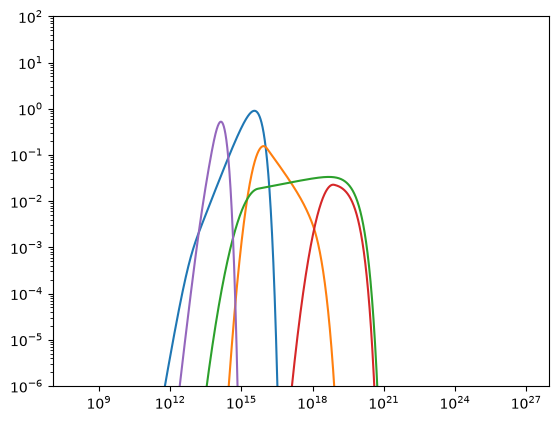

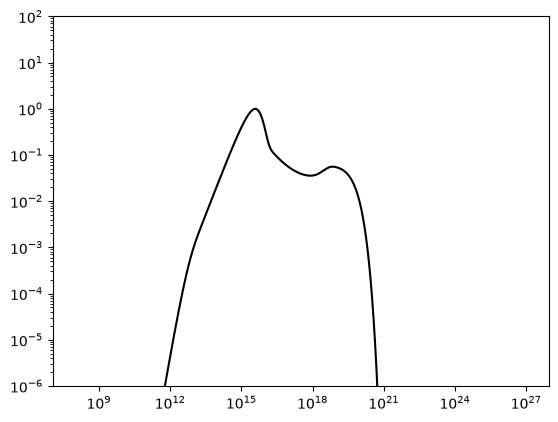

done


In [182]:
# =============================================================#
#                        Auxiliary Code                        #
# =============================================================#

### Helper Functions ###

def lo(nu, spec, cut = 1.0, w = 0.5):
    x = np.log10(nu / cut)
    return spec * np.where(x >= 0, 1.0, np.exp(-(x**2) / (2 * w**2)))

def hi(nu, spec, cut = 1.0, w = 0.5):
    x = np.log10(nu / cut)
    return spec * np.where(x <= 0, 1.0, np.exp(-(x**2) / (2 * w**2)))


### Defining Constants ###

h = 6.626e-27
c = 2.998e10
k = 1.381e-16
G = 6.674e-8
Msun = 1.989e33
eV = 1.602e-12
keV = 1e3 * eV
sigma_SB = 5.670e-5


### Central Engine ###

Msmbh = 1e8 * Msun
lamEdd = 0.1                       # L_bol / L_Edd
lumEdd = 1.26e38 * (Msmbh / Msun)        # erg/s, standard Eddington luminosity
Lbol = lamEdd * lumEdd             # ~1.26e45 erg/s

fdisk = 0.7
Ldisk = fdisk * Lbol

Rg = G * M_BH / c**2
Rin = 6 * Rg                          # ISCO, non-spinning BH
Rout = 1e5 * Rg

nu = np.logspace(8, 27, 6000)


# =============================================================#
#                       Physical Spectra                       #
# =============================================================#

### Clumpy Dusty ###

def torus(nu, temps=(1200, 400, 10), weights=(0.15, 1.0, 1.3), beta=1.5):
    E = np.zeros_like(nu)
    for T, w in zip(temps, weights):
        E += w * nu**beta * bb(nu, T)
    return nu * E

    
### Accretion Disk ###

def bb(nu, T):
    x = h * nu / (k * np.maximum(T, 1))
    x = np.clip(x, 1e-10, 700)
    return (2 * h * nu**3 / c**2) / np.expm1(x)

def ss(r):
    Mdot = Ldisk / (0.1 * c**2)
    x = r / Rin
    prof = np.maximum(1 - x**(-1/2), 0.0)
    temp = (3 * G * Msmbh * Mdot) / (8 * np.pi * sigma_SB * r**3) * prof
    return temp**(1/4)

def disk(nu, a = 1):
    r = np.logspace(np.log10(Rin), np.log10(Rout), 101)
    dr = np.diff(r)
    r = np.sqrt(r[:-1] * r[1:])
    T = ss(r)
    Lnu = np.zeros_like(nu)
    for Ti, ri, dri in zip(T, r, dr):
        if Ti <= 10:
            continue
        Lnu += bb(nu, Ti) * ri * dri
    return a * nu * Lnu


### Soft Excess ###

def excess(nu, a, Gamma = 2.7, Ecut_keV = 6):
    E_keV = h * nu / keV
    spec = nu**(2 - Gamma) * np.exp(-E_keV / Ecut_keV)
    return a * hi(nu, lo(nu, spec, 1.2e16, 0.3), 1e18)


### Hot Corona ###

Gcor = 1.9

def corona(nu, a, Gamma = Gcor, Ecut_keV = 200):
    E_keV = h * nu / keV
    spec = nu**(2 - Gamma) * np.exp(-E_keV / Ecut_keV)
    return a * lo(nu, spec, 5e15)


### Reflected Component ###

def reflection(nu, a, Gamma = Gcor, Enull_keV = 20, Ecut_keV = 150, shift = 9.99e20):
    E_keV = h * (nu + shift) / keV
    spec = nu**(2 - Gamma) * (E_keV / Enull_keV) * np.exp(-E_keV / Ecut_keV)
    return a * lo(nu, spec, 8e18, 0.4)


### Radio Lobes ###

def lobe():
    return 0


### Gamma Jet ###

def jet():
    return 0




### Output Generation ###

plt.plot(nu, disk(nu, 1e-43))
plt.plot(nu, excess(nu, 2.5e10))
plt.plot(nu, corona(nu, 5e-4))
plt.plot(nu, reflection(nu, 1.6e6))
plt.plot(nu, 1e-28 * torus(nu))

plt.ylim(1e-6, 1e2)

plt.xscale('log')
plt.yscale('log')

plt.show()




plt.plot(nu, disk(nu, 1e-43) + excess(nu, 2.5e10) + corona(nu, 5e-4) + reflection(nu, 1.6e6), 'k')

plt.ylim(1e-6, 1e2)

plt.xscale('log')
plt.yscale('log')

plt.show()

print('done')